## Import Libraries

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

In [35]:
df = pd.read_csv("../data/deliveries.csv")

## Initial Exploration

In [36]:
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          260920 non-null  int64
 1   inning            260920 non-null  int64
 2   batting_team      260920 non-null  str  
 3   bowling_team      260920 non-null  str  
 4   over              260920 non-null  int64
 5   ball              260920 non-null  int64
 6   batter            260920 non-null  str  
 7   bowler            260920 non-null  str  
 8   non_striker       260920 non-null  str  
 9   batsman_runs      260920 non-null  int64
 10  extra_runs        260920 non-null  int64
 11  total_runs        260920 non-null  int64
 12  extras_type       14125 non-null   str  
 13  is_wicket         260920 non-null  int64
 14  player_dismissed  12950 non-null   str  
 15  dismissal_kind    12950 non-null   str  
 16  fielder           9354 non-null    str  
dtypes: int64(8), str(9)
m

In [38]:
df.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')

## CORE GROUPBY ANALYSIS

### Top Run Scorers

In [39]:
top_runs = (
    df.groupby("batter")["batsman_runs"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_runs)

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


### Most Sixes

In [40]:
sixes = df[df["batsman_runs"] == 6]

top_sixes = (
    sixes.groupby("batter")["batsman_runs"]
         .count()
         .sort_values(ascending=False)
         .head(10)
)

print(top_sixes)

batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
Name: batsman_runs, dtype: int64


### Team-wise Runs

In [41]:
team_runs = (
    df.groupby("batting_team")["total_runs"]
      .sum()
      .sort_values(ascending=False)
)

print(team_runs)

batting_team
Mumbai Indians                 42176
Kolkata Knight Riders          39331
Chennai Super Kings            38629
Royal Challengers Bangalore    37692
Rajasthan Royals               34747
Kings XI Punjab                30064
Sunrisers Hyderabad            29071
Delhi Daredevils               24296
Delhi Capitals                 14900
Deccan Chargers                11463
Punjab Kings                    9536
Gujarat Titans                  7757
Lucknow Super Giants            7510
Pune Warriors                   6358
Gujarat Lions                   4862
Royal Challengers Bengaluru     2930
Rising Pune Supergiant          2470
Rising Pune Supergiants         2063
Kochi Tuskers Kerala            1901
Name: total_runs, dtype: int64


### Strike Rate Analysis

In [42]:
player_stats = (
    df.groupby("batter")
      .agg(
          runs=("batsman_runs", "sum"),
          balls=("ball", "count")
      )
)

player_stats["strike_rate"] = (
    player_stats["runs"] / player_stats["balls"]
) * 100

player_stats = player_stats[player_stats["balls"] > 500]

top_sr = player_stats.sort_values(
    by="strike_rate",
    ascending=False
).head(10)

print(top_sr)

                 runs  balls  strike_rate
batter                                   
AD Russell       2488   1515   164.224422
H Klaasen         993    613   161.990212
SP Narine        1534    984   155.894309
N Pooran         1769   1143   154.768154
LS Livingstone    939    609   154.187192
GJ Maxwell       2772   1842   150.488599
RM Patidar        799    534   149.625468
Abhishek Sharma  1377    925   148.864865
V Sehwag         2728   1833   148.827059
AB de Villiers   5181   3487   148.580442


### Top Run Scorers Chart

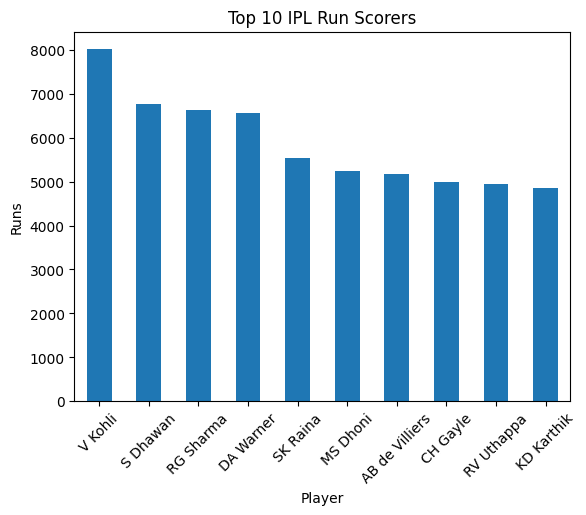

In [43]:
top_runs.plot(kind="bar")

plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Player")
plt.ylabel("Runs")

plt.xticks(rotation=45)
plt.show()

### Insights Section
• Virat Kohli appears among the top run scorers consistently.
• Certain players maintain high strike rates with large ball counts.
• Team batting performance varies significantly across franchises.